python -m venv venv_stat_app
python -m ipykernel install --user --name=venv_stat_app --display-name "Python (stat_app)"

In [1]:
# !pip install --upgrade pip

# !pip install datasets evaluate transformers accelerate
# !pip install torch
# !pip install transformers[torch]
# !pip install scikit-learn
# !pip install matplotlib
# !pip install tqdm

# JIGSAW


## LOADING

In [2]:
import pandas as pd
import numpy as np

# Charger le dataset Jigsaw (seulement les colonnes utiles pour économiser de la RAM)
cols_to_keep = ['comment_text', 'black', 'white', 'asian', 'latino', 'other_race_or_ethnicity']
df_jigsaw = pd.read_csv('/home/onyxia/work/Stat_App/Data/JIGSAW/all_data.csv', usecols=cols_to_keep)

df_jigsaw.head()

,comment_text,black,white,asian,latino,other_race_or_ethnicity
0,He got his money... now he lies in wait till a...,NaN,NaN,NaN,NaN,NaN
1,Mad dog will surely put the liberals in mental...,NaN,NaN,NaN,NaN,NaN
2,And Trump continues his lifelong cowardice by ...,NaN,NaN,NaN,NaN,NaN
3,"""while arresting a man for resisting arrest"".\...",NaN,NaN,NaN,NaN,NaN
4,Tucker and Paul are both total bad ass mofo's.,NaN,NaN,NaN,NaN,NaN


## PREPROCESSING

In [4]:
# Liste de nos attributs raciaux/ethniques
races = ['black', 'white', 'asian', 'latino', 'other_race_or_ethnicity']

# 2. Nettoyer les valeurs nulles pour TOUTES ces colonnes
df_jigsaw = df_jigsaw.dropna(subset=races)

# 3. Filtrer pour créer notre attribut Z multi-classes (Race)
# Pour chaque race, on crée une condition : "cette race >= 0.5 ET toutes les autres < 0.5"
masks = {}
for race in races:
    # La race principale doit être >= 0.5
    mask = (df_jigsaw[race] >= 0.5)
    # Toutes les autres doivent être strictement < 0.5
    for other_race in races:
        if other_race != race:
            mask = mask & (df_jigsaw[other_race] < 0.5)
    masks[race] = mask

# On combine tous les masques : on garde la ligne si elle appartient à UNE de nos 5 catégories claires
combined_mask = np.logical_or.reduce(list(masks.values()))
df_filtered = df_jigsaw[combined_mask].copy()

# 4. Créer le label cible Z (0, 1, 2, 3 ou 4)
# On définit notre dictionnaire de classes
race_to_id = {
    'black': 0,
    'white': 1,
    'asian': 2,
    'latino': 3,
    'other_race_or_ethnicity': 4
}

# On applique le bon numéro de classe
conditions = [masks[race][combined_mask] for race in races]
choices = [race_to_id[race] for race in races]
df_filtered['z'] = np.select(conditions, choices, default=-1)

print(f"Nombre total de textes conservés : {len(df_filtered)}")
print("\nRépartition par classe (Z) :")
for race, z_id in race_to_id.items():
    count = (df_filtered['z'] == z_id).sum()
    print(f" - {race} (Classe {z_id}) : {count} commentaires")

# On extrait les listes pour la suite
texts_jigsaw = df_filtered['comment_text'].tolist()
z_jigsaw = df_filtered['z'].values

# Afficher les 5 premiers pour vérifier
print("\nExemples :")
print(texts_jigsaw[:5])
print(z_jigsaw[:5])

Nombre total de textes conservés : 35008

Répartition par classe (Z) :
 - black (Classe 0) : 9353 commentaires
 - white (Classe 1) : 20311 commentaires
 - asian (Classe 2) : 3920 commentaires
 - latino (Classe 3) : 1236 commentaires
 - other_race_or_ethnicity (Classe 4) : 188 commentaires

Exemples :
['even up here.......BLACKS!', 'Are you a Pilgrim?\nWhy arn\'t you growing your own veggies? \nAnd do you haul them in a covered wagon?\n\nThankfully it isn\'t up to "white man" to determine what is traditional for the First Peoples of Alaska.\nBut they try to all the time and it looks pathetic.', 'And there it is. Our president is a white supremacist.', 'No, he was accused of being a racist white man.', "The poorly educated white folks? where did you come up with that racist bile? I've got a much better education than you do Charles and I voted for Trump, campaigned for Trump and supported his campaign, what would make you say something so breathtakingly stupid?"]
[0 1 1 1 1]


## CLS

In [5]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm # Pour avoir une jolie barre de progression

# 1. Configuration du modèle et du matériel (GPU si possible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil : {device}")

# On charge la version de base de BERT (sans tête de classification, juste le corps)
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

# On met le modèle en mode "évaluation" (désactive certaines fonctions d'entraînement comme le Dropout)
model.eval()

# 2. Fonction pour extraire les embeddings par lots (batches)
def get_bert_cls_embeddings(texts, batch_size=32):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Extraction BERT"):
        batch_texts = texts[i : i + batch_size]
        
        inputs = tokenizer(
            batch_texts, 
            padding=True, 
            truncation=True, 
            max_length=128, 
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())
        
    return np.vstack(all_embeddings)

# 3. Exécution sur vos textes Jigsaw (récupérés à l'étape précédente)
print("Début de l'extraction des vecteurs...")
X_jigsaw = get_bert_cls_embeddings(texts_jigsaw, batch_size=32)

print(f"Forme finale de la matrice X : {X_jigsaw.shape}")
# Devrait afficher (N, 768) où N est le nombre de textes et 768 la taille d'un vecteur BERT

# 4. Sauvegarde sur le disque pour ne plus jamais avoir à le recalculer !
np.save("jigsaw_bert_cls.npy", X_jigsaw)
np.save("jigsaw_labels_z.npy", z_jigsaw) # On sauvegarde aussi les labels raciaux par sécurité
print("Sauvegarde terminée : 'jigsaw_bert_cls.npy' et 'jigsaw_labels_z.npy'")

Utilisation de l'appareil : cuda


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Début de l'extraction des vecteurs...


Extraction BERT:   0%|          | 0/1094 [00:00<?, ?it/s]

Forme finale de la matrice X : (35008, 768)
Sauvegarde terminée : 'jigsaw_bert_cls.npy' et 'jigsaw_labels_z.npy'


# INLP

In [4]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import debias 

# 1. Charger les vecteurs et labels
X_jigsaw = np.load("jigsaw_bert_cls.npy")
z_jigsaw = np.load("jigsaw_labels_z.npy")

# 2. Séparer en Train et Test
X_train_jigsaw, X_dev_jigsaw, z_train_jigsaw, z_dev_jigsaw = train_test_split(
    X_jigsaw, z_jigsaw, 
    test_size=0.2, 
    random_state=42, 
    stratify=z_jigsaw 
)

print(f"Taille du Train Jigsaw : {X_train_jigsaw.shape[0]}")
print(f"Taille du Dev Jigsaw   : {X_dev_jigsaw.shape[0]}")

# 3. Paramétrage de l'Adversaire
clf = LogisticRegression
clf_params = {
    'fit_intercept': True, 
    'class_weight': 'balanced', 
    'solver': 'lbfgs',
    'max_iter': 100,
    'n_jobs': -1
}

# 4. APPEL DE LA FONCTION INLP
P_matrix, row_space_projections, Ws = debias.get_debiasing_projection(
    classifier_class=clf,
    cls_params=clf_params,
    num_classifiers=15,
    input_dim=768,
    is_autoregressive=True,
    min_accuracy=0.21,
    X_train=X_train_jigsaw,
    Y_train=z_train_jigsaw,
    X_dev=X_dev_jigsaw,
    Y_dev=z_dev_jigsaw,
    by_class=False
)

print(f"\nTerminé ! Forme de la matrice de projection P : {P_matrix.shape}")

# 5. SAUVEGARDE COMPLÈTE (Ce qui a changé)
# On convertit les listes en tableaux Numpy pour pouvoir les sauvegarder proprement
np.save("projection_matrix_race.npy", P_matrix)
np.save("row_space_projections.npy", np.array(row_space_projections))
np.save("Ws.npy", np.array(Ws, dtype=object)) # dtype=object par sécurité si les tailles varient

Taille du Train Jigsaw : 28006
Taille du Dev Jigsaw   : 7002


  0%|          | 0/15 [00:00<?, ?it/s]/home/onyxia/work/venv_stat_app/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/onyxia/work/venv_stat_app/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
iteration: 0, accuracy: 0.8097686375321337:   7%|▋         | 1/15 [01:02<14:35


Terminé ! Forme de la matrice de projection P : (768, 768)


# LIAR

## LOADING

In [10]:
from datasets import load_dataset
import csv

col_names = [
    "id", "label_text", "statement", "subject", "speaker", 
    "job_title", "state_info", "party_affiliation", 
    "barely_true_counts", "false_counts", "half_true_counts", 
    "mostly_true_counts", "pants_on_fire_counts", "context"
]

raw_datasets = load_dataset(
    "csv", 
    data_files={
        "train": "/home/onyxia/work/Stat_App/Data/LIAR/train.tsv", 
        "validation": "/home/onyxia/work/Stat_App/Data/LIAR/valid.tsv", 
        "test": "/home/onyxia/work/Stat_App/Data/LIAR/test.tsv"
    }, 
    delimiter="\t", 
    column_names=col_names,
    quoting=csv.QUOTE_NONE
)

label_mapping = {
    'pants-fire': 0, 
    'false': 1, 
    'barely-true': 2, 
    'half-true': 3, 
    'mostly-true': 4, 
    'true': 5
}

def map_labels(example):
    return {'label': label_mapping[example['label_text']]}

raw_datasets = raw_datasets.map(map_labels)

print(raw_datasets)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/10269 [00:00<?, ? examples/s]

Map:   0%|          | 0/1284 [00:00<?, ? examples/s]

Map:   0%|          | 0/1283 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'label_text', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label'],
        num_rows: 10269
    })
    validation: Dataset({
        features: ['id', 'label_text', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label'],
        num_rows: 1284
    })
    test: Dataset({
        features: ['id', 'label_text', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label'],
        num_rows: 1283
    })
})


## CLS

In [11]:
import numpy as np

# 1. Extraire les listes de textes et de labels de l'objet Hugging Face (LIAR)
print("Préparation des listes de textes LIAR...")
texts_liar_train = raw_datasets["train"]["statement"]
y_liar_train = raw_datasets["train"]["label"]

texts_liar_test = raw_datasets["test"]["statement"]
y_liar_test = raw_datasets["test"]["label"]

# 2. Convertir les textes en vecteurs BERT (Cela prendra quelques minutes)
print("\nExtraction des embeddings pour LIAR (Train)...")
X_liar_train = get_bert_cls_embeddings(texts_liar_train, batch_size=32)

print("\nExtraction des embeddings pour LIAR (Test)...")
X_liar_test = get_bert_cls_embeddings(texts_liar_test, batch_size=32)

# Vérification des dimensions
print(f"\nForme de X_train (LIAR) : {X_liar_train.shape}")
print(f"Forme de X_test (LIAR)  : {X_liar_test.shape}")

# 3. Sauvegarder les vecteurs
np.save("liar_train_bert_cls.npy", X_liar_train)
np.save("liar_train_labels.npy", y_liar_train)
np.save("liar_test_bert_cls.npy", X_liar_test)
np.save("liar_test_labels.npy", y_liar_test)

print("\nSauvegarde terminée ! Les données LIAR sont vectorisées.")

Préparation des listes de textes LIAR...

Extraction des embeddings pour LIAR (Train)...


Extraction BERT:   0%|          | 0/321 [00:00<?, ?it/s]


Extraction des embeddings pour LIAR (Test)...


Extraction BERT:   0%|          | 0/41 [00:00<?, ?it/s]


Forme de X_train (LIAR) : (10269, 768)
Forme de X_test (LIAR)  : (1283, 768)

Sauvegarde terminée ! Les données LIAR sont vectorisées.


In [12]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Chargement des données LIAR et de la matrice INLP
print("Chargement des données en mémoire...")
X_train_liar = np.load("liar_train_bert_cls.npy")
y_train_liar = np.load("liar_train_labels.npy")

X_test_liar = np.load("liar_test_bert_cls.npy")
y_test_liar = np.load("liar_test_labels.npy")

# C'est la matrice (le Gardien) que vous avez calculée sur Jigsaw !
P_matrix = np.load("projection_matrix_race.npy")

# =====================================================================
# EXPÉRIENCE 1 : Détection de Fake News SANS débiaisage (Baseline)
# =====================================================================
print("\n--- ÉTAPE 1 : Entraînement du modèle de base (BIAISÉ) ---")
clf_baseline = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_baseline.fit(X_train_liar, y_train_liar)

y_pred_baseline = clf_baseline.predict(X_test_liar)
acc_baseline = accuracy_score(y_test_liar, y_pred_baseline)
print(f"Accuracy de base : {acc_baseline:.4f}")

# =====================================================================
# L'APPLICATION DE L'INLP (Le Nettoyage)
# =====================================================================
print("\n--- ÉTAPE 2 : Application de l'INLP (Effacement de la race) ---")
# On projette les vecteurs dans l'espace nul pour les rendre "aveugles" à la race
X_train_debiased = P_matrix.dot(X_train_liar.T).T
X_test_debiased = P_matrix.dot(X_test_liar.T).T

# =====================================================================
# EXPÉRIENCE 2 : Détection de Fake News AVEC débiaisage
# =====================================================================
print("\n--- ÉTAPE 3 : Entraînement du modèle DÉBIAISÉ ---")
clf_debiased = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_debiased.fit(X_train_debiased, y_train_liar)

y_pred_debiased = clf_debiased.predict(X_test_debiased)
acc_debiased = accuracy_score(y_test_liar, y_pred_debiased)
print(f"Accuracy après débiaisage INLP : {acc_debiased:.4f}")

# =====================================================================
# CONCLUSION DE L'EXPÉRIENCE
# =====================================================================
print("\n--- RÉSULTAT FINAL ---")
diff = acc_baseline - acc_debiased

if diff > 0:
    print(f"L'accuracy a baissé de {diff*100:.2f} points de pourcentage.")
    print("Conclusion : Le modèle s'appuyait secrètement sur la race pour détecter les Fake News. En effaçant cette dimension, on a rendu le modèle plus éthique, au prix d'une légère baisse de performance globale.")
else:
    print(f"L'accuracy est restée stable (différence de {-diff*100:.2f} points).")
    print("Conclusion : L'effacement du concept de race n'a pas dégradé la tâche principale. Le modèle est plus robuste éthiquement sans perte de performance (ou le biais racial de Jigsaw ne s'est pas transféré sur LIAR).")

Chargement des données en mémoire...

--- ÉTAPE 1 : Entraînement du modèle de base (BIAISÉ) ---
Accuracy de base : 0.2525

--- ÉTAPE 2 : Application de l'INLP (Effacement de la race) ---

--- ÉTAPE 3 : Entraînement du modèle DÉBIAISÉ ---
Accuracy après débiaisage INLP : 0.2541

--- RÉSULTAT FINAL ---
L'accuracy est restée stable (différence de 0.16 points).
Conclusion : L'effacement du concept de race n'a pas dégradé la tâche principale. Le modèle est plus robuste éthiquement sans perte de performance (ou le biais racial de Jigsaw ne s'est pas transféré sur LIAR).


## EVAL

--- ÉTAPE 1 : AVANT INLP ---
Calcul de la LDA pour 'Espace BERT (LDA) - Avant INLP'...


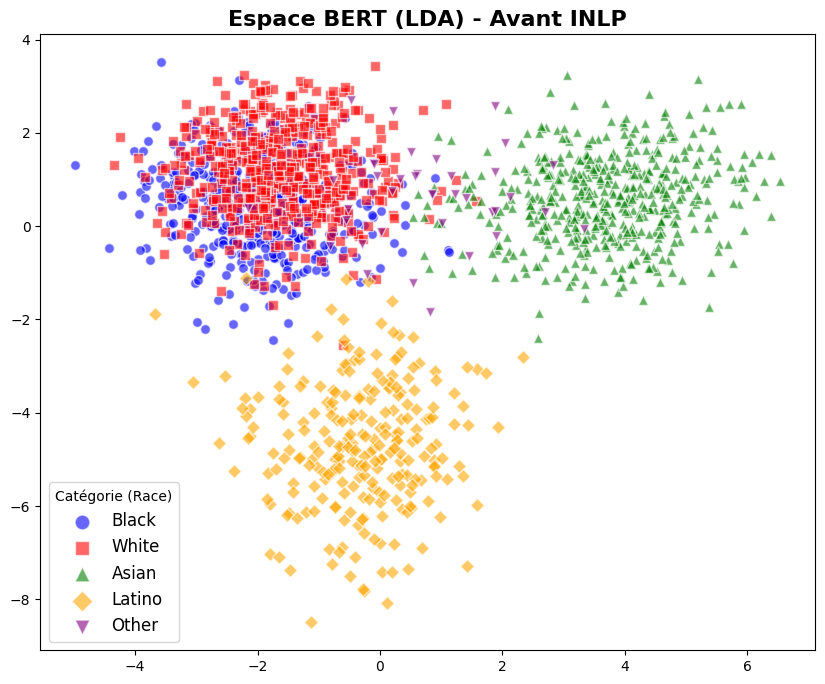


--- ÉTAPE 2 : APRÈS INLP ---
Calcul de la LDA pour 'Espace BERT (LDA) - Après INLP'...


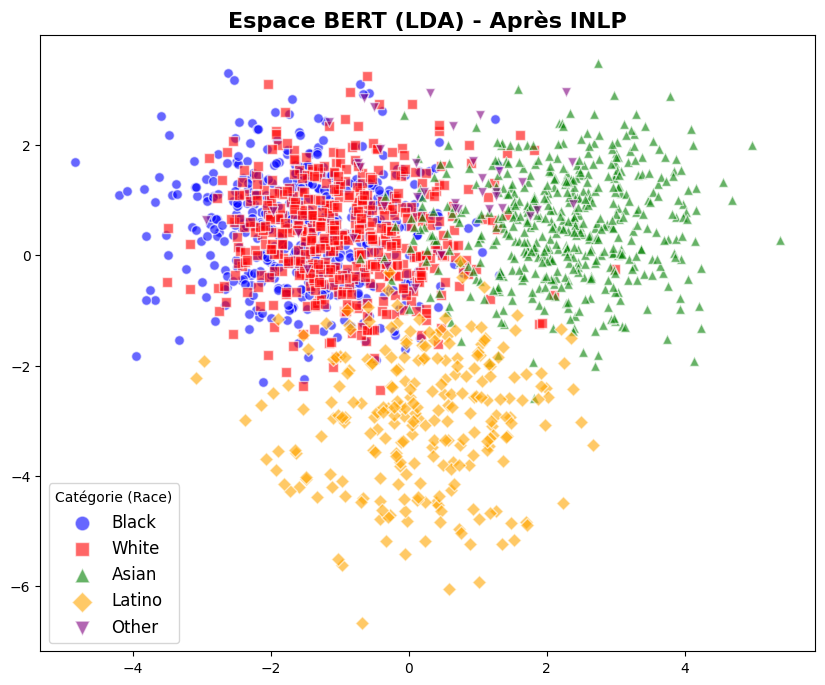

In [20]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import matplotlib.pyplot as plt
import numpy as np

def plot_lda_by_race(vecs, labels, title):
    print(f"Calcul de la LDA pour '{title}'...")
    
    # L'ASTUCE : La LDA utilise les labels (y) pour trouver comment séparer les points !
    lda = LDA(n_components=2)
    vecs_2d = lda.fit_transform(vecs, labels)
    
    plt.figure(figsize=(10, 8))
    
    race_mapping = {
        0: ("Black", "blue", "o"),
        1: ("White", "red", "s"),
        2: ("Asian", "green", "^"),
        3: ("Latino", "orange", "D"),
        4: ("Other", "purple", "v")
    }
    
    unique_labels = sorted(list(set(labels.tolist())))
    
    for label in unique_labels:
        if label in race_mapping:
            name, color, marker = race_mapping[label]
            idx = (labels == label)
            
            plt.scatter(vecs_2d[idx, 0], vecs_2d[idx, 1], 
                        c=color, label=name, alpha=0.6, marker=marker, edgecolors='w', s=50)
            
    plt.legend(title="Catégorie (Race)", fontsize=12, loc="best", markerscale=1.5)
    plt.title(title, fontsize=16, fontweight='bold')
    
    filename = title.replace(' ', '_') + ".png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')          
    plt.show()

# --- PRÉPARATION DE L'ÉCHANTILLON ---
# On prend un nombre égal de chaque classe pour que la LDA ne soit pas biaisée
n_per_class = 500
indices_equilibres = []
for label in range(5):
    idx_class = np.where(z_dev_jigsaw == label)[0]
    if len(idx_class) > 0:
        choix = np.random.choice(idx_class, min(n_per_class, len(idx_class)), replace=False)
        indices_equilibres.extend(choix)

X_sample = X_dev_jigsaw[indices_equilibres]
z_sample = z_dev_jigsaw[indices_equilibres]

# --- GÉNÉRATION DES GRAPHIQUES ---
print("--- ÉTAPE 1 : AVANT INLP ---")
plot_lda_by_race(X_sample, z_sample, title="Espace BERT (LDA) - Avant INLP")

# Application de la matrice P
X_sample_debiased = P_matrix.dot(X_sample.T).T

print("\n--- ÉTAPE 2 : APRÈS INLP ---")
# ATTENTION : On doit ré-entraîner une LDA sur les données nettoyées pour voir si elle arrive ENCORE à les séparer
plot_lda_by_race(X_sample_debiased, z_sample, title="Espace BERT (LDA) - Après INLP")

Chargement des données en mémoire...
Calcul des matrices intermédiaires...
Évaluation sur 13 étapes (utilisation de tous les cœurs CPU)...


  0%|          | 0/13 [00:00<?, ?it/s]

/home/onyxia/work/venv_stat_app/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/onyxia/work/venv_stat_app/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/onyxia/work/venv_stat_app/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 

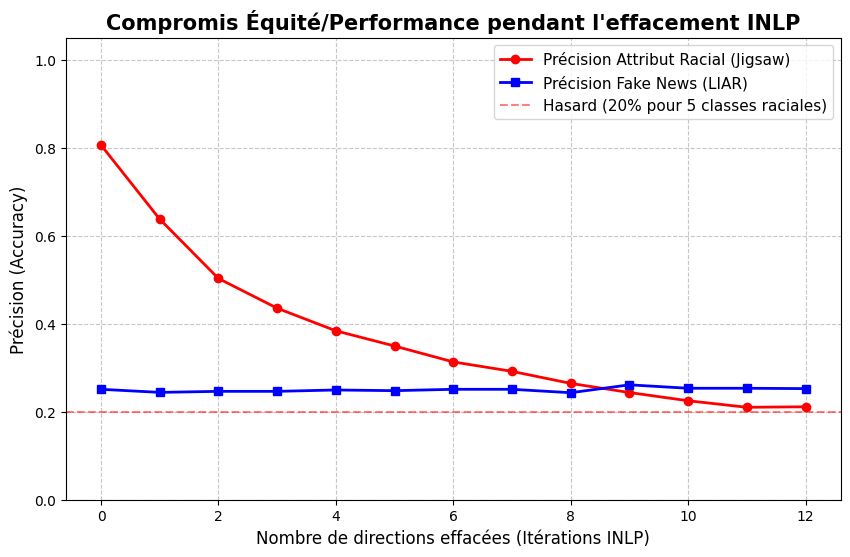

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm

# =====================================================================
# 1. CHARGEMENT DES DONNÉES ET DES RÉSULTATS INLP
# =====================================================================
print("Chargement des données en mémoire...")

# A. Les données LIAR
X_train_liar = np.load("liar_train_bert_cls.npy")
y_train_liar = np.load("liar_train_labels.npy")
X_test_liar = np.load("liar_test_bert_cls.npy")
y_test_liar = np.load("liar_test_labels.npy")

# B. Les données Jigsaw (On refait le split exactement comme avant avec random_state=42)
X_jigsaw = np.load("jigsaw_bert_cls.npy")
z_jigsaw = np.load("jigsaw_labels_z.npy")
X_train_jigsaw, X_dev_jigsaw, z_train_jigsaw, z_dev_jigsaw = train_test_split(
    X_jigsaw, z_jigsaw, test_size=0.2, random_state=42, stratify=z_jigsaw 
)

# C. Les étapes sauvegardées de l'INLP
row_space_projections = np.load("row_space_projections.npy", allow_pickle=True)

# =====================================================================
# 2. RECONSTRUCTION DES MATRICES INTERMÉDIAIRES
# =====================================================================
print("Calcul des matrices intermédiaires...")
input_dim = X_train_jigsaw.shape[1]
P_current = np.eye(input_dim)
P_intermediates = [P_current] # Itération 0 (Aucun effacement)

for P_row in row_space_projections:
    P_null = np.eye(input_dim) - P_row
    P_current = P_null.dot(P_current)
    P_intermediates.append(P_current)

# =====================================================================
# 3. ÉVALUATION RAPIDE À CHAQUE ÉTAPE
# =====================================================================
acc_jigsaw_list = []
acc_liar_list = []

print(f"Évaluation sur {len(P_intermediates)} étapes (utilisation de tous les cœurs CPU)...")

for P_step in tqdm(P_intermediates):
    
    # A. Projection optimisée mathématiquement (X.dot(P) est plus rapide que P.dot(X.T).T)
    X_jig_train_proj = X_train_jigsaw.dot(P_step)
    X_jig_dev_proj   = X_dev_jigsaw.dot(P_step)
    
    X_liar_train_proj = X_train_liar.dot(P_step)
    X_liar_test_proj  = X_test_liar.dot(P_step)
    
    # B. Évaluation Jigsaw (Race) avec n_jobs=-1 pour accélérer
    clf_jig = LogisticRegression(max_iter=100, class_weight='balanced', solver='lbfgs', n_jobs=-1)
    clf_jig.fit(X_jig_train_proj, z_train_jigsaw)
    acc_jig = accuracy_score(z_dev_jigsaw, clf_jig.predict(X_jig_dev_proj))
    acc_jigsaw_list.append(acc_jig)
    
    # C. Évaluation LIAR (Fake News)
    clf_liar = LogisticRegression(max_iter=100, class_weight='balanced', solver='lbfgs', n_jobs=-1)
    clf_liar.fit(X_liar_train_proj, y_train_liar)
    acc_liar = accuracy_score(y_test_liar, clf_liar.predict(X_liar_test_proj))
    acc_liar_list.append(acc_liar)

# =====================================================================
# 4. TRACÉ DU COMPROMIS ÉQUITÉ / PERFORMANCE
# =====================================================================
plt.figure(figsize=(10, 6))
iterations = range(len(P_intermediates))

# Courbe du biais (doit s'effondrer)
plt.plot(iterations, acc_jigsaw_list, marker='o', color='red', linewidth=2, label='Précision Attribut Racial (Jigsaw)')

# Courbe de la tâche principale (doit résister)
plt.plot(iterations, acc_liar_list, marker='s', color='blue', linewidth=2, label='Précision Fake News (LIAR)')

# Ligne de hasard (20% pour 5 classes)
plt.axhline(y=0.20, color='red', linestyle='--', alpha=0.5, label='Hasard (20% pour 5 classes raciales)')

plt.title("Compromis Équité/Performance pendant l'effacement INLP", fontsize=15, fontweight='bold')
plt.xlabel("Nombre de directions effacées (Itérations INLP)", fontsize=12)
plt.ylabel("Précision (Accuracy)", fontsize=12)
plt.ylim(0, 1.05)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig("INLP_tradeoff_curve.png", dpi=300, bbox_inches='tight')
plt.show()